# Regression Analysis Notebook from the Uploaded Slide

This notebook translates the main ideas from the uploaded regression-analysis slide deck into runnable Python:
- linear model setup
- OLS and the normal equations
- fitted values, residuals, and the hat matrix
- Gauss-Markov intuition
- GLS / weighted regression intuition
- normal-theory regression and MLE
- robust M-estimation and quantile regression
- a real-world finance example using market data

## Source slide
This notebook is based on the uploaded slide deck **Regression Analysis (MIT 18.S096, Lecture 6)**.

## 1) Concept map from the slide

The slide centers on the linear model

$$
y = X\beta + \varepsilon
$$

where:
- $y$ is the response vector
- $X$ is the design matrix of explanatory variables
- $\beta$ is the vector of regression coefficients
- $\varepsilon$ is the error term

### OLS objective
Ordinary Least Squares chooses $\hat{\beta}$ to minimize

$$
Q(\beta) = (y - X\beta)^\top (y - X\beta)
$$

Taking derivatives and setting them equal to zero gives the **normal equations**

$$
X^\top X \hat{\beta} = X^\top y
$$

so, when $X^\top X$ is invertible,

$$
\hat{\beta} = (X^\top X)^{-1}X^\top y
$$

### Fitted values and hat matrix
$$
\hat{y} = X\hat{\beta} = H y,
\qquad
H = X(X^\top X)^{-1}X^\top
$$

The residual vector is

$$
\hat{\varepsilon} = y - \hat{y}
$$

and OLS residuals satisfy

$$
X^\top \hat{\varepsilon} = 0
$$

which means residuals are orthogonal to the column space of $X$.

### Gauss-Markov assumptions
The slide states the usual conditions:

$$
E(Y \mid X) = X\beta, \qquad \text{Cov}(Y \mid X) = \sigma^2 I
$$

Under these assumptions, OLS is **BLUE**:
**Best Linear Unbiased Estimator**.

### GLS
If errors are correlated or have unequal variances,

$$
\text{Cov}(Y \mid X) = \sigma^2 \Sigma
$$

then the GLS estimator becomes

$$
\hat{\beta}_{GLS} = (X^\top \Sigma^{-1} X)^{-1} X^\top \Sigma^{-1} y
$$

### Normal linear model and MLE
If errors are i.i.d. normal,

$$
\varepsilon_i \sim N(0,\sigma^2)
$$

then OLS is also the maximum-likelihood estimator for $\beta$.

### Beyond OLS
The slide also introduces:
- MAD / LAD style estimation
- robust M-estimation
- quantile regression

In [1]:
# If needed, uncomment the next line the first time you run this notebook
# %pip install yfinance statsmodels pandas matplotlib numpy scipy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot

np.set_printoptions(suppress=True, precision=6)
pd.set_option("display.float_format", "{:.6f}".format)

## 2) A small synthetic example: verify the OLS formula by hand

We first generate simple linear data and compute $\hat{\beta}$ manually using matrix algebra.

In [2]:
rng = np.random.default_rng(42)

n = 100
x = np.linspace(-2, 2, n)
eps = rng.normal(loc=0.0, scale=1.0, size=n)

beta_true = np.array([1.5, 2.0])  # intercept, slope
X = np.column_stack([np.ones(n), x])
y = X @ beta_true + eps

# Manual OLS:
# beta_hat = (X'X)^(-1) X'y
# In code, solve(X'X, X'y) is numerically better than explicitly taking the inverse.
beta_hat_manual = np.linalg.solve(X.T @ X, X.T @ y)

beta_hat_manual

array([1.44973 , 1.895118])

### Interpretation

The first coefficient is the estimated intercept, and the second is the estimated slope.

Even though the slide writes

$$
\hat{\beta} = (X^\top X)^{-1} X^\top y
$$

using `np.linalg.solve` is usually better in practice because it solves the same linear system more stably.

In [3]:
# Compare against statsmodels OLS
ols_synth = sm.OLS(y, X).fit()

comparison = pd.DataFrame({
    "true_beta": beta_true,
    "manual_ols": beta_hat_manual,
    "statsmodels_ols": ols_synth.params
}, index=["intercept", "slope"])

comparison

,true_beta,manual_ols,statsmodels_ols
intercept,1.500000,1.449730,1.449730
slope,2.000000,1.895118,1.895118


In [4]:
# Fitted values, residuals, hat matrix, and orthogonality check
H = X @ np.linalg.inv(X.T @ X) @ X.T
y_hat = H @ y
resid = y - y_hat

orthogonality_check = X.T @ resid

print("Max absolute difference between manual fitted values and statsmodels fitted values:",
      np.max(np.abs(y_hat - ols_synth.fittedvalues)))
print("\nX' e-hat (should be very close to 0):")
print(orthogonality_check)

Max absolute difference between manual fitted values and statsmodels fitted values: 1.7763568394002505e-15

X' e-hat (should be very close to 0):
[-0. -0.]


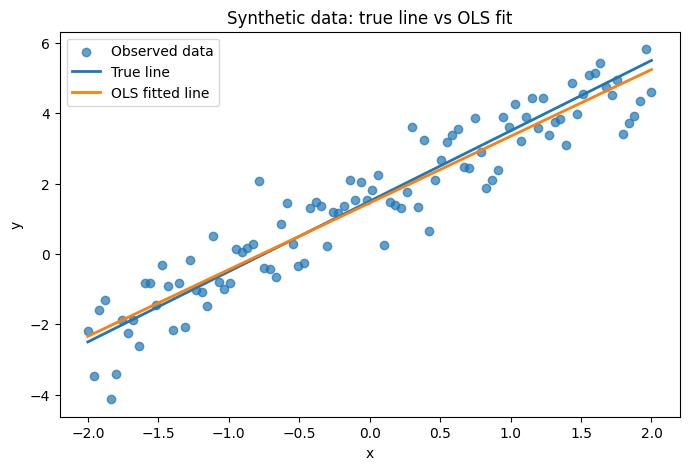

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, alpha=0.7, label="Observed data")
ax.plot(x, X @ beta_true, linewidth=2, label="True line")
ax.plot(x, y_hat, linewidth=2, label="OLS fitted line")
ax.set_title("Synthetic data: true line vs OLS fit")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

## 3) Connecting theory to inference

Under the normal linear model, the slide gives these major results:

- $\hat{\beta}$ is normally distributed
- $\hat{\beta}$ and residuals are independent
- the residual sum of squares leads to a chi-squared result
- each coefficient can be tested with a $t$-statistic

In practice, `statsmodels` packages these results in the regression summary.

In [6]:
print(ols_synth.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     822.3
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.85e-49
Time:                        13:19:40   Log-Likelihood:                -114.85
No. Observations:                 100   AIC:                             233.7
Df Residuals:                      98   BIC:                             238.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4497      0.077     18.808      0.0

## 4) Real-world finance use case: the market model

A classic finance application of linear regression is the **market model**:

$$
r_{stock,t} = \alpha + \beta \, r_{market,t} + \varepsilon_t
$$

Here:
- $r_{stock,t}$ is the stock return at time $t$
- $r_{market,t}$ is the market return at time $t$
- $\alpha$ is the intercept
- $\beta$ measures market sensitivity

### Why this matters in finance
This is useful for:
- estimating a stock's sensitivity to the market
- separating systematic risk from idiosyncratic noise
- stress testing how a stock might react when the market moves
- building factor models and risk dashboards

In [7]:
import yfinance as yf

ticker_stock = "AAPL"
ticker_market = "SPY"
start_date = "2026-01-01"

raw = yf.download(
    [ticker_stock, ticker_market],
    start=start_date,
    auto_adjust=True,
    progress=False
)

if raw.empty:
    raise ValueError("No market data was downloaded. Check your internet connection or ticker symbols.")

# With multiple tickers, yfinance usually returns a MultiIndex and we can select the Close panel directly.
close = raw["Close"].dropna()

returns = np.log(close / close.shift(1)).dropna()
returns.columns = ["stock_ret", "market_ret"]

returns.head()

,stock_ret,market_ret
Date,,
2026-01-05,-0.013934,0.006638
2026-01-06,-0.018504,0.005930
2026-01-07,-0.007768,-0.003229
2026-01-08,-0.004967,-0.000102
2026-01-09,0.001273,0.006592


### Notes on the data
- We use **adjusted price history** through `auto_adjust=True`, which is convenient for return analysis.
- We use **log returns**:
$$
r_t = \log(P_t / P_{t-1})
$$
because they are easy to aggregate over time and commonly used in finance.

In [8]:
X_fin = sm.add_constant(returns["market_ret"])
y_fin = returns["stock_ret"]

ols_fin = sm.OLS(y_fin, X_fin).fit()

print(ols_fin.summary())

                            OLS Regression Results                            
Dep. Variable:              stock_ret   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     26.57
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           2.99e-06
Time:                        13:20:06   Log-Likelihood:                 181.55
No. Observations:                  62   AIC:                            -359.1
Df Residuals:                      60   BIC:                            -354.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.002     -0.188      0.8

In [9]:
alpha_hat = ols_fin.params["const"]
beta_hat = ols_fin.params["market_ret"]
r2 = ols_fin.rsquared

print(f"Estimated alpha : {alpha_hat:.6f}")
print(f"Estimated beta  : {beta_hat:.4f}")
print(f"R-squared       : {r2:.4f}")

Estimated alpha : -0.000315
Estimated beta  : 0.9661
R-squared       : 0.3069


### Finance interpretation
- **Beta > 1**: the stock tends to move more than the market.
- **Beta < 1**: the stock tends to move less than the market.
- **Positive alpha**: the fitted intercept is above zero over the sample.
- **R-squared**: the share of stock-return variation explained by market-return variation.

This is not a trading rule by itself. It is a **risk and sensitivity model**.

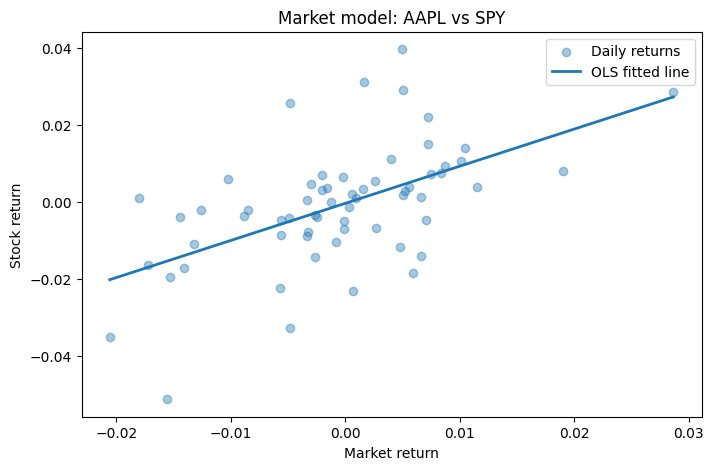

In [10]:
# Plot stock return vs market return with fitted line
x_vals = np.linspace(returns["market_ret"].min(), returns["market_ret"].max(), 200)
y_vals = alpha_hat + beta_hat * x_vals

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(returns["market_ret"], returns["stock_ret"], alpha=0.4, label="Daily returns")
ax.plot(x_vals, y_vals, linewidth=2, label="OLS fitted line")
ax.set_title(f"Market model: {ticker_stock} vs {ticker_market}")
ax.set_xlabel("Market return")
ax.set_ylabel("Stock return")
ax.legend()
plt.show()

## 5) Residual diagnostics

The slide emphasizes checking model assumptions. For finance data, this matters a lot because returns can have:
- volatility clustering
- heavy tails
- outliers
- regime changes

We will inspect:
1. residuals vs fitted values
2. a Q-Q plot
3. a Breusch-Pagan heteroskedasticity test

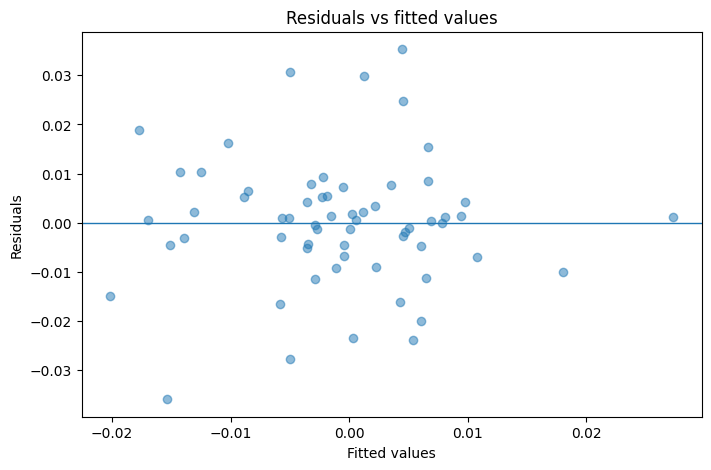

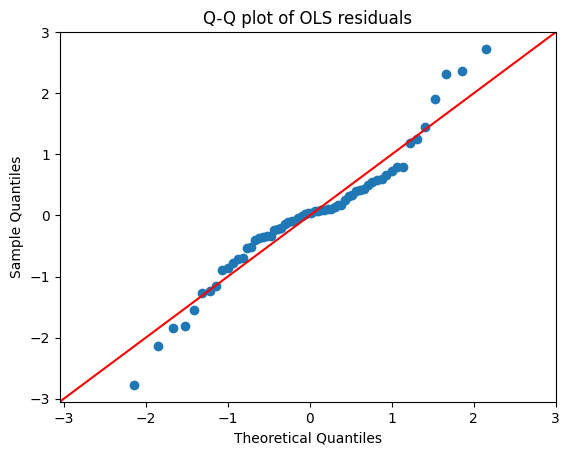

LM stat      0.696428
LM p-value   0.403986
F stat       0.681619
F p-value    0.412300
dtype: float64

In [11]:
resid_fin = ols_fin.resid
fitted_fin = ols_fin.fittedvalues

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted_fin, resid_fin, alpha=0.5)
ax.axhline(0, linewidth=1)
ax.set_title("Residuals vs fitted values")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
plt.show()

qqplot(resid_fin, line="45", fit=True)
plt.title("Q-Q plot of OLS residuals")
plt.show()

bp_test = het_breuschpagan(resid_fin, X_fin)
bp_results = pd.Series(
    bp_test,
    index=["LM stat", "LM p-value", "F stat", "F p-value"]
)
bp_results

### Reading the diagnostics
- A fan shape in the residual plot suggests heteroskedasticity.
- Large deviations from the 45-degree line in the Q-Q plot suggest non-normal tails.
- A small Breusch-Pagan p-value suggests non-constant variance.

That is exactly why the slide moves beyond plain OLS into GLS and robust approaches.

## 6) A GLS-like improvement: weighted least squares

A full GLS model needs a covariance matrix $\Sigma$. In practice, a common approximation is to use **WLS** with weights related to inverse variance.

Below, we use a simple proxy:
- estimate rolling market variance
- give lower weight to observations from high-volatility periods

This is not the only way to set weights, but it is a concrete bridge from OLS to GLS thinking.

In [12]:
vol_proxy = returns["market_ret"].rolling(20).var().shift(1)
wls_df = returns.copy()
wls_df["vol_proxy"] = vol_proxy
wls_df = wls_df.dropna()

X_wls = sm.add_constant(wls_df["market_ret"])
y_wls = wls_df["stock_ret"]

weights = 1 / wls_df["vol_proxy"]
wls_fin = sm.WLS(y_wls, X_wls, weights=weights).fit()

coef_compare = pd.DataFrame({
    "OLS": ols_fin.params,
    "WLS": wls_fin.params
})

coef_compare

,OLS,WLS
const,-0.000315,0.000520
market_ret,0.966094,0.881552


## 7) Robust M-estimation

The slide also discusses robust M-estimation. This is helpful in finance because a few extreme days can pull OLS estimates more than we want.

Here we fit a robust linear model with a Huber loss.

In [13]:
rlm_fin = sm.RLM(y_fin, X_fin, M=sm.robust.norms.HuberT()).fit()

robust_compare = pd.DataFrame({
    "OLS": ols_fin.params,
    "Robust_Huber": rlm_fin.params
})

robust_compare

,OLS,Robust_Huber
const,-0.000315,-0.000373
market_ret,0.966094,0.861364


## 8) Quantile regression

The slide ends with quantile estimators. In finance, this is useful because the relationship between stock and market returns may look different in:
- bad days
- typical days
- strong up days

We estimate the 10th, 50th, and 90th conditional quantiles.

In [14]:
q10 = sm.QuantReg(y_fin, X_fin).fit(q=0.10)
q50 = sm.QuantReg(y_fin, X_fin).fit(q=0.50)
q90 = sm.QuantReg(y_fin, X_fin).fit(q=0.90)

quantile_compare = pd.DataFrame({
    "OLS_mean": ols_fin.params,
    "Q10": q10.params,
    "Q50": q50.params,
    "Q90": q90.params
})

quantile_compare

,OLS_mean,Q10,Q50,Q90
const,-0.000315,-0.016577,0.000303,0.012594
market_ret,0.966094,1.008015,0.922027,0.639624


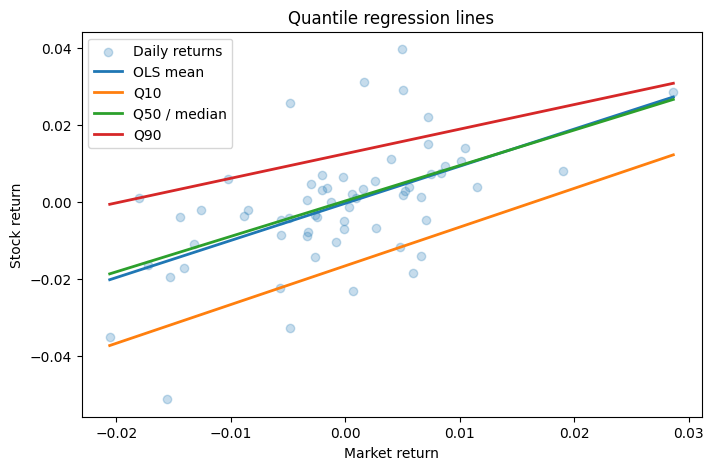

In [15]:
x_vals = np.linspace(returns["market_ret"].min(), returns["market_ret"].max(), 200)

line_ols = ols_fin.params["const"] + ols_fin.params["market_ret"] * x_vals
line_q10 = q10.params["const"] + q10.params["market_ret"] * x_vals
line_q50 = q50.params["const"] + q50.params["market_ret"] * x_vals
line_q90 = q90.params["const"] + q90.params["market_ret"] * x_vals

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(returns["market_ret"], returns["stock_ret"], alpha=0.25, label="Daily returns")
ax.plot(x_vals, line_ols, linewidth=2, label="OLS mean")
ax.plot(x_vals, line_q10, linewidth=2, label="Q10")
ax.plot(x_vals, line_q50, linewidth=2, label="Q50 / median")
ax.plot(x_vals, line_q90, linewidth=2, label="Q90")
ax.set_title("Quantile regression lines")
ax.set_xlabel("Market return")
ax.set_ylabel("Stock return")
ax.legend()
plt.show()

### Why quantile regression is useful in finance
If the 10th-quantile slope is much steeper than the OLS slope, the stock may be more sensitive on weak-market days than the average-line model suggests.

That makes quantile regression useful for:
- downside-risk analysis
- tail behavior studies
- stress testing and scenario analysis

## 9) Rolling beta

A single regression over the full sample assumes the relationship is stable. In finance, it often is not.

A simple way to see time variation is a rolling beta.

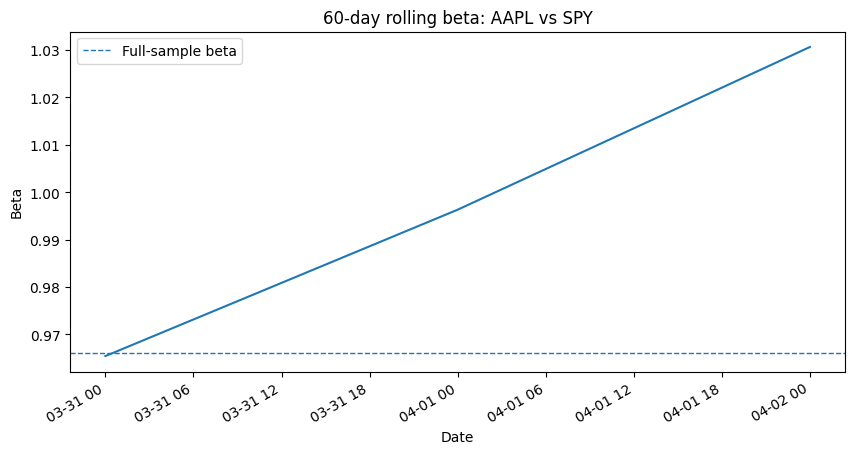

In [16]:
window = 60

rolling_beta = (
    returns["stock_ret"].rolling(window).cov(returns["market_ret"]) /
    returns["market_ret"].rolling(window).var()
)

fig, ax = plt.subplots(figsize=(10, 5))
rolling_beta.plot(ax=ax)
ax.axhline(beta_hat, linewidth=1, linestyle="--", label="Full-sample beta")
ax.set_title(f"{window}-day rolling beta: {ticker_stock} vs {ticker_market}")
ax.set_ylabel("Beta")
ax.legend()
plt.show()

## 10) Scenario table

This turns the fitted regression into a simple sensitivity table.

In [17]:
scenarios = pd.DataFrame({
    "market_return": [-0.03, -0.02, -0.01, 0.00, 0.01, 0.02, 0.03]
})

scenario_X = sm.add_constant(scenarios, has_constant="add")

scenarios["pred_stock_return_OLS"] = ols_fin.predict(scenario_X)
scenarios["pred_stock_return_Robust"] = rlm_fin.predict(scenario_X)
scenarios["pred_stock_return_Q10"] = q10.predict(scenario_X)
scenarios["pred_stock_return_Q90"] = q90.predict(scenario_X)

scenarios

,market_return,pred_stock_return_OLS,pred_stock_return_Robust,pred_stock_return_Q10,pred_stock_return_Q90
0,-0.030000,-0.029298,-0.026214,-0.046817,-0.006595
1,-0.020000,-0.019637,-0.017601,-0.036737,-0.000199
2,-0.010000,-0.009976,-0.008987,-0.026657,0.006197
3,0.000000,-0.000315,-0.000373,-0.016577,0.012594
4,0.010000,0.009346,0.008240,-0.006497,0.018990
5,0.020000,0.019007,0.016854,0.003583,0.025386
6,0.030000,0.028668,0.025468,0.013664,0.031782


## 11) Business-style conclusion

From the slide to finance practice:

1. **OLS** gives a clean baseline estimate of alpha and beta.
2. **Gauss-Markov** explains why OLS is attractive when errors are homoskedastic and uncorrelated.
3. **GLS / WLS** becomes useful when variance changes over time.
4. **Normal-theory regression** gives t-tests, confidence intervals, and standard summaries.
5. **MLE** matches OLS for $\beta$ under normal errors.
6. **Robust M-estimation** helps when a few extreme market days distort the line.
7. **Quantile regression** helps when downside behavior differs from average behavior.

So the slide is not just theory. It maps directly into practical finance workflows:
- beta estimation
- factor exposure analysis
- stress testing
- tail-risk analysis
- portfolio risk monitoring

## 12) Ideas for extension

You can easily extend this notebook by:
- replacing `AAPL` with any stock or ETF
- adding more factors, such as sector ETFs or interest-rate proxies
- switching from daily to weekly or monthly returns
- using excess returns if you want a stricter CAPM-style setup
- comparing several stocks in one notebook
- building a small risk dashboard from rolling betas and residual volatility